# Fitting a PDF at a Fixed Scale (91.18 GeV)

The first of the three primary objectives of this Bachelor's Thesis is to perform a fit of a Parton Distribution Function (PDF) (as given by LHAPDF) at a fixed scale of $Q = 91.18$ GeV.
This first objective will focus on building a neural network to fit the PDFs using Machine Learning techniques to observe the dynamic behavior of protons. This is quite useful as it helps to understand the initial state of partons inside the proton before a collision.

In [11]:
import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from collections import defaultdict
from lhapdf import mkPDF, setVerbosity
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from tensorflow import keras
from utils.functions import pid_to_latex

tf.keras.backend.clear_session()
setVerbosity(0)

# Reading the DATA from LHAPDF, we will use the NNPDF40_nnlo_as_01180 set.
pdf_set = "NNPDF40_nnlo_as_01180/0"
pdf_target = mkPDF(pdf_set)

# Defining the scale at which we want to fit the PDF, in this case the Z boson mass.
q0 = 91.1876  # GeV
npoints = int(1e5)  # How many points to use for training

print(f"Data of {pdf_set} for Q = {q0} GeV")

Data of NNPDF40_nnlo_as_01180/0 for Q = 91.1876 GeV


## 1. Visualization of experimental data.
Before we start creating our NN model, we will plot experimental data from some PDFs so we can examine them.

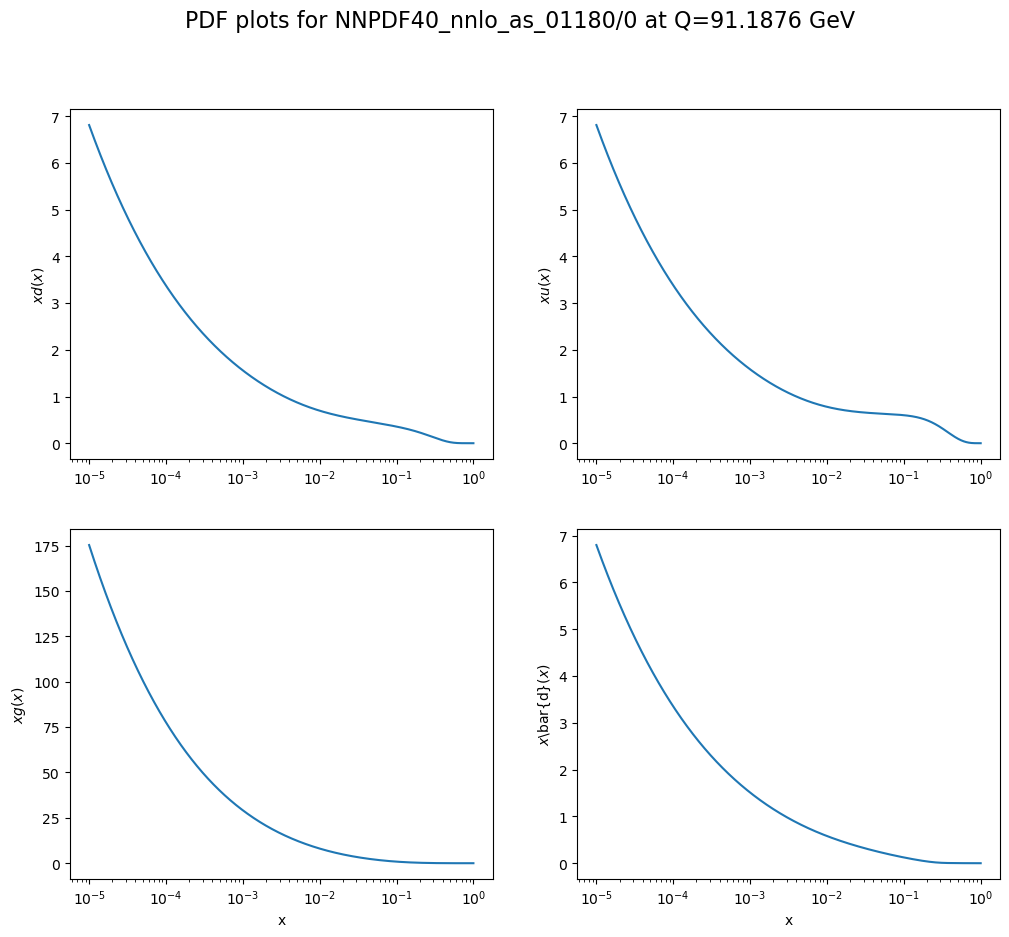

In [12]:
# We will use a logarithmic grid in x to capture the behavior at small x, and a linear grid at large x to capture the behavior near 1.
xgrid = np.concatenate(
    (np.logspace(-5, -1, npoints // 2), np.linspace(0.1, 1, npoints // 2))
)
input_xgrid = xgrid.reshape(-1, 1)

# This will give us a list of dictionaries, where each dictionary contains the PDF values for all partons at a given x and Q^2.
pdf_grid_all = pdf_target.xfxQ2(xgrid, np.ones_like(xgrid) * q0**2)

# We will plot some PDFs to inspect them visually.
flavour_select = [1, 2, 21, -1]  # Up, Down, Gluon, Anti-Up
pdf_grid = defaultdict(list)

for point in pdf_grid_all:
    for pid in flavour_select:
        pdf_grid[pid_to_latex(pid)].append(point[pid])

fig, ax = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"PDF plots for {pdf_set} at Q={q0} GeV", fontsize=16)
for i, (parton, val) in enumerate(pdf_grid.items()):
    plt.subplot(2, 2, i + 1)

    plt.plot(xgrid, val, label=f"{parton} PDF")
    plt.legend
    plt.xscale("log")
    if i > 1:
        plt.xlabel("x")
    plt.ylabel(f"$x{parton}(x)$")
plt.show()

We can observe that the input data involves different scales and wich require some form of preprocessing of the input.

In [ ]:
c, b = np.histogram(xgrid)
cl, bl = np.histogram(np.log(xgrid))

plt.subplots(1, 2, figsize=(11, 4))
plt.subplot(1, 2, 1)
plt.title("Linear")
plt.stairs(c, b, fill=True)
plt.xlabel("x")
plt.ylabel("N")
plt.subplot(1, 2, 2)
plt.title("Log")
plt.stairs(cl, bl, fill=True)
plt.xlabel("log(x)")
plt.ylabel("N")

## 2. NN - PDF
To create our model with TensorFlow, we will build custom layers with physical meaning. One of them will use a logarithmic scale to approximate the behavior at very small $x$ scales. We will also add another custom layer to our network to ensure that the limit as $x$ approaches 1 is $x = 0$ using the factor: $(1-x)^{\beta+1}$
- **InputScaling**: Introduce $\log(x)$.
- **Preprocessing**: Ensure the limit $x \to 1$.

In [1]:
class InputScaling(tf.keras.layers.Layer):
    def call(self, x):
        return tf.concat([x, tf.math.log(x + 1e-10)], axis=-1)


class Preprocessing(tf.keras.layers.Layer):
    def build(self, input_shape):
        self._beta = self.add_weight(
            shape=(1,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="beta",
            constraint=tf.keras.constraints.non_neg(),
        )

    def call(self, x):
        return (1.0 - x) ** (self._beta + 1.0)


def generate_model():
    inputs = tf.keras.layers.Input(shape=(1,))
    scaled = InputScaling()(inputs)
    x = tf.keras.layers.Dense(32, activation="tanh")(scaled)
    x = tf.keras.layers.Dense(32, activation="tanh")(x)
    x = tf.keras.layers.Dense(32, activation="tanh")(x)
    pdf_raw = tf.keras.layers.Dense(1, activation="linear")(x)
    preproc = Preprocessing()(inputs)
    final_results = tf.keras.layers.Multiply()([pdf_raw, preproc])
    return tf.keras.models.Model(inputs=inputs, outputs=final_results)

NameError: name 'tf' is not defined

## 3. Training: Gluon
First, we will perform the training for a specific parton; in our case, the gluon. To do this, we will use normalized values. Normalizing allows the network to focus exclusively on learning the functional form and the quantum dynamics (the curvature) of each parton. This prevents the huge difference in magnitude between the gluon and the quarks from biasing the learning toward the component with the higher momentum density. Later, when checking the results, we denormalize the obtained values so that they have physical meaning.

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0132 - val_loss: 9.7119e-05
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0020 - val_loss: 1.2864e-04
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 2.2874e-04
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.1756e-04 - val_loss: 1.1619e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.5700e-04 - val_loss: 5.7389e-05
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7671e-04 - val_loss: 2.3697e-05
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.1222e-04 - val_loss: 5.7168e-06
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.1363e-04 - val_loss: 7.1602e-07
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2896e-04 - val_loss: 2.0822e-06
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.4231e-04 - val_loss: 9.8912e-06
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.9565e-04

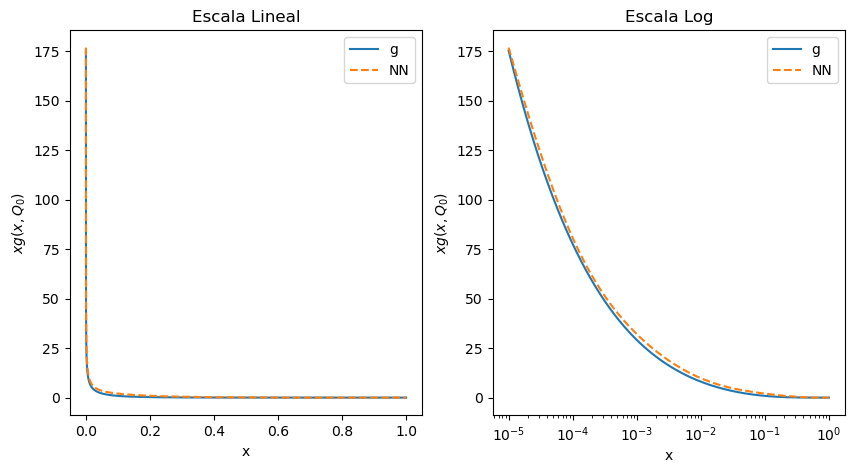

In [14]:
target_pid = 21  # Gluon
name = pid_to_latex(target_pid)
parton_data = np.array([pdf_grid[target_pid] for pdf_grid in pdf_grid_all]).reshape(
    -1, 1
)
max_val = np.max(parton_data)
parton_data_norm = parton_data / max_val

model = generate_model()
model.compile(optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse")


history = model.fit(
    input_xgrid,
    parton_data_norm,
    epochs=50,
    validation_split=0.3,
    batch_size=512,
    verbose=1,
)

predictions = model.predict(input_xgrid) * max_val

plt.figure(figsize=(10, 5))

# Plot Lineal
plt.subplot(1, 2, 1)
plt.plot(xgrid, parton_data, label="g")
plt.plot(xgrid, predictions, label="NN", linestyle="--")
plt.title("Escala Lineal")
plt.xlabel("x")
plt.ylabel(rf"$x{name}(x, Q_{0})$")
plt.legend()

# Plot Log
plt.subplot(1, 2, 2)
plt.plot(xgrid, parton_data, label="g")
plt.plot(xgrid, predictions, label="NN", linestyle="--")
plt.xscale("log")
plt.title("Escala Log")
plt.xlabel("x")
plt.ylabel(rf"$x{name}(x, Q_{0})$")
plt.legend()

plt.show()

## 4. Multiflavour Fit
As we can see, the previous model fits the experimental data quite well. However, there are actually 9 partons that contribute to forming the proton: the u, d, c, and s quarks and their antiparticles. The model does not really change; it will have the same inputs but will now have 9 different outputs, one for each flavor.

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0174 - val_loss: 3.2442e-04
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0031 - val_loss: 7.8570e-05
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0014 - val_loss: 9.1318e-05
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8.7686e-04 - val_loss: 1.8131e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6145e-04 - val_loss: 1.5059e-04
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.8038e-04 - val_loss: 9.3541e-05
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.9146e-04 - val_loss: 6.5113e-05
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.2360e-04 - val_loss: 4.8642e-05
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 3.5257e-04 - val_loss: 2.3093e-05
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.6085e-04 - val_loss: 1.7511e-05
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.3619e-04

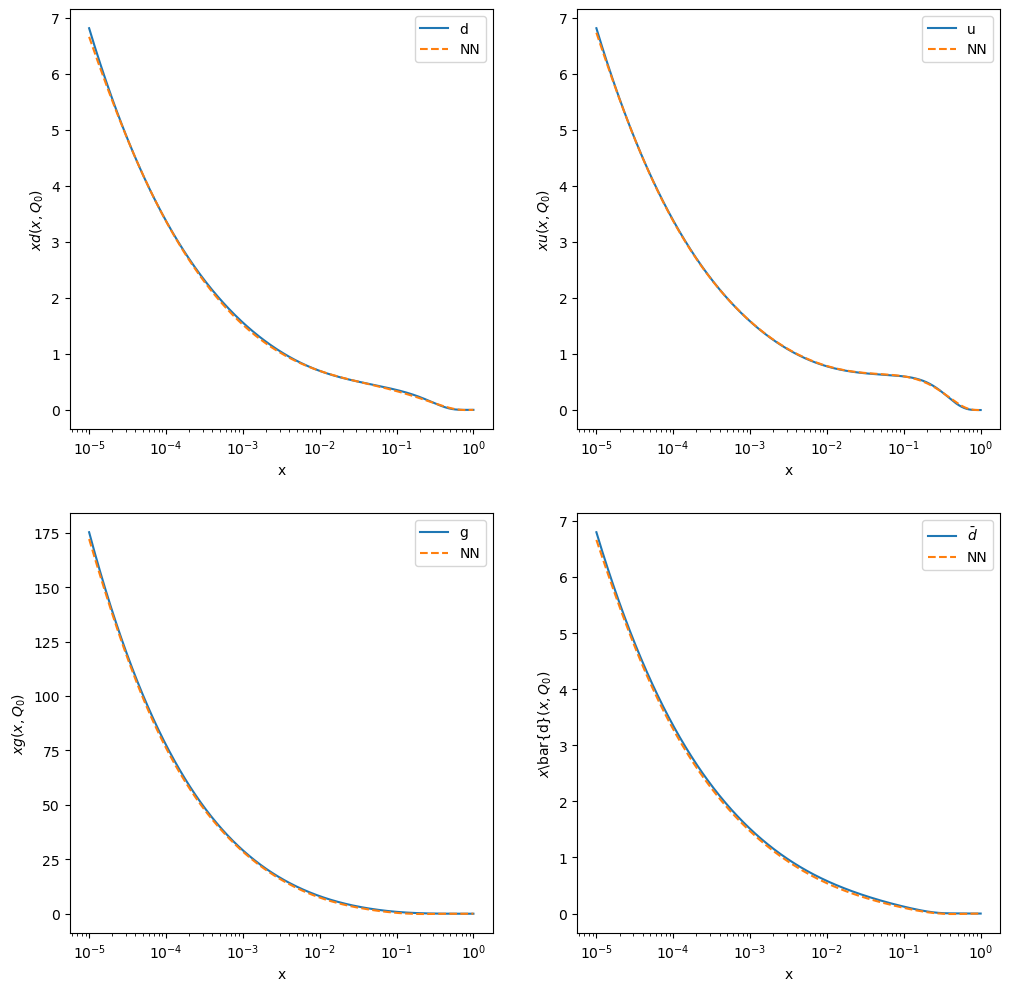

In [15]:
output_basis = [
    -4,
    -3,
    -2,
    -1,
    21,
    1,
    2,
    3,
    4,
]  # anti-charm, anti-strange, anti-up, anti-down, gluon, down, up, strange, charm
noutput = len(output_basis)

output_data = np.zeros((len(pdf_grid_all), noutput))

for i, pdf_grid in enumerate(pdf_grid_all):
    for j, pid in enumerate(output_basis):
        output_data[i, j] = pdf_grid[pid]

output_data = np.array(output_data)

# Normalize each column by its maximum value
max_vals = np.max(output_data, axis=0)
output_data_norm = output_data / max_vals


# Now the beta parameter in the Preprocessing layer should be a vector of length noutput, and we will multiply each output by its corresponding (1-x)^beta_i.
class PreprocessingMulti(tf.keras.layers.Layer):
    def __init__(self, noutput, **kwargs):
        super().__init__(**kwargs)
        self.noutput = noutput

    def build(self, input_shape):
        # Beta is now a vector of length noutput, one for each output flavor
        self._beta = self.add_weight(
            shape=(self.noutput,),
            initializer=tf.keras.initializers.Constant(1.0),
            trainable=True,
            name="beta",
            constraint=tf.keras.constraints.non_neg(),
        )

    def call(self, x):
        # We need to apply (1-x)^(1+beta_i) to each output i, so we will expand the dimensions of x and beta to do this multiplication correctly.
        return (1.0 - x) ** (self._beta + 1.0)


# The model architecture will be similar to the single flavor case, but now we will have noutput outputs, and we will use the PreprocessingMulti layer to apply the correct behavior at large x for each flavor.
def pdf_model_multiflavour(input_shape=(1,)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    scaled = InputScaling()(inputs)
    x = tf.keras.layers.Dense(64, activation="tanh")(scaled)
    x = tf.keras.layers.Dense(64, activation="tanh")(x)
    x = tf.keras.layers.Dense(64, activation="tanh")(x)

    raw_pdf_multiflavour = tf.keras.layers.Dense(noutput, activation="linear")(x)
    preproc_multiflavour = PreprocessingMulti(noutput)(inputs)

    final_results_multiflavour = tf.keras.layers.Multiply()(
        [raw_pdf_multiflavour, preproc_multiflavour]
    )

    return tf.keras.models.Model(inputs=inputs, outputs=final_results_multiflavour)


model_multiflavour = pdf_model_multiflavour()
model_multiflavour.compile(
    optimizer=keras.optimizers.Nadam(learning_rate=0.0005), loss="mse"
)
history_multiflavour = model_multiflavour.fit(
    input_xgrid, output_data_norm, epochs=50, validation_split=0.3, batch_size=512
)

predictions_multiflavour_norm = model_multiflavour.predict(input_xgrid)
predictions_multiflavour = predictions_multiflavour_norm * max_vals

plt.subplots(2, 2, figsize=(12, 12))
for i, pid in enumerate([1, 2, 21, -1]):
    idx = output_basis.index(pid)
    name = pid_to_latex(pid)

    plt.subplot(2, 2, i + 1)
    plt.plot(xgrid, output_data[:, idx], label=name)
    plt.plot(xgrid, predictions_multiflavour[:, idx], label="NN", linestyle="--")
    plt.xscale("log")
    plt.xlabel("x")
    plt.ylabel(rf"$x{name}(x, Q_{0})$")
    plt.legend()

plt.show()